In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# python source path
sys.path.append('../Src/')

# custom python 
import z_score

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Pyarrow": pa.__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int64 = pd.ArrowDtype(pa.int64())
arrow_bool = pd.ArrowDtype(pa.bool8())

      Library Version
0      Python  3.13.9
1      Pandas   2.3.3
2       NumPy   2.3.4
3  Matplotlib  3.10.7
4     Seaborn  0.13.2
5     Pyarrow  22.0.0


In [2]:
# Read Arrow IPC file
with open('../Data/crime_data.arrow', 'rb') as f:
    reader = ipc.open_file(f)
    table = reader.read_all()
    
# Convert back to pandas (Arrow‑backed)
df = table.to_pandas(types_mapper=pd.ArrowDtype)

#### Calculating the Z-score highlights specialized anomalies—places where a specific crime type is occurring at a rate far beyond what is statistically normal for the rest of the city.
- A Z-score of 3.0
    - The value is higher than about 99.87% of all values in a normal distribution 
    - It’s an extreme outlier
- A Z‑score of 2 means:
    - The value is higher than about 97.7% of all values in a normal distribution
    - That year’s count is significantly higher than the historical average
- A Z-score of -1:
    - The value is lower than about 84% of all values
    - It’s a mild decrease, not extreme

In [3]:
# 1. Aggregate counts
yearly = (
    df.groupby(['year', 'fbi_code_desc'], observed=False)
    .size()
    .reset_index(name='count')
)

# Vectorized Z-Score calculation using transform
# This avoids creating a separate 'baseline' table and merging manually
group = yearly.groupby('fbi_code_desc', observed=False)['count']
yearly['mean_type'] = group.transform('mean')
# "safe" replacement for a zero standard deviation keep the math stable)
yearly['std_type'] = group.transform('std').fillna(1).replace(0, 1)

# 3. Calculate Z-Score
yearly['z_score'] = (yearly['count'] - yearly['mean_type']) / yearly['std_type']

# 4. Handle edge cases (Infinity or remains of NaN)
yearly['z_score'] = yearly['z_score'].replace([np.inf, -np.inf], 0).fillna(0)

# 5. Pivot for Heatmap/Grid Analysis
z_pivot = yearly.pivot(index="fbi_code_desc", columns="year", values="z_score").fillna(0)

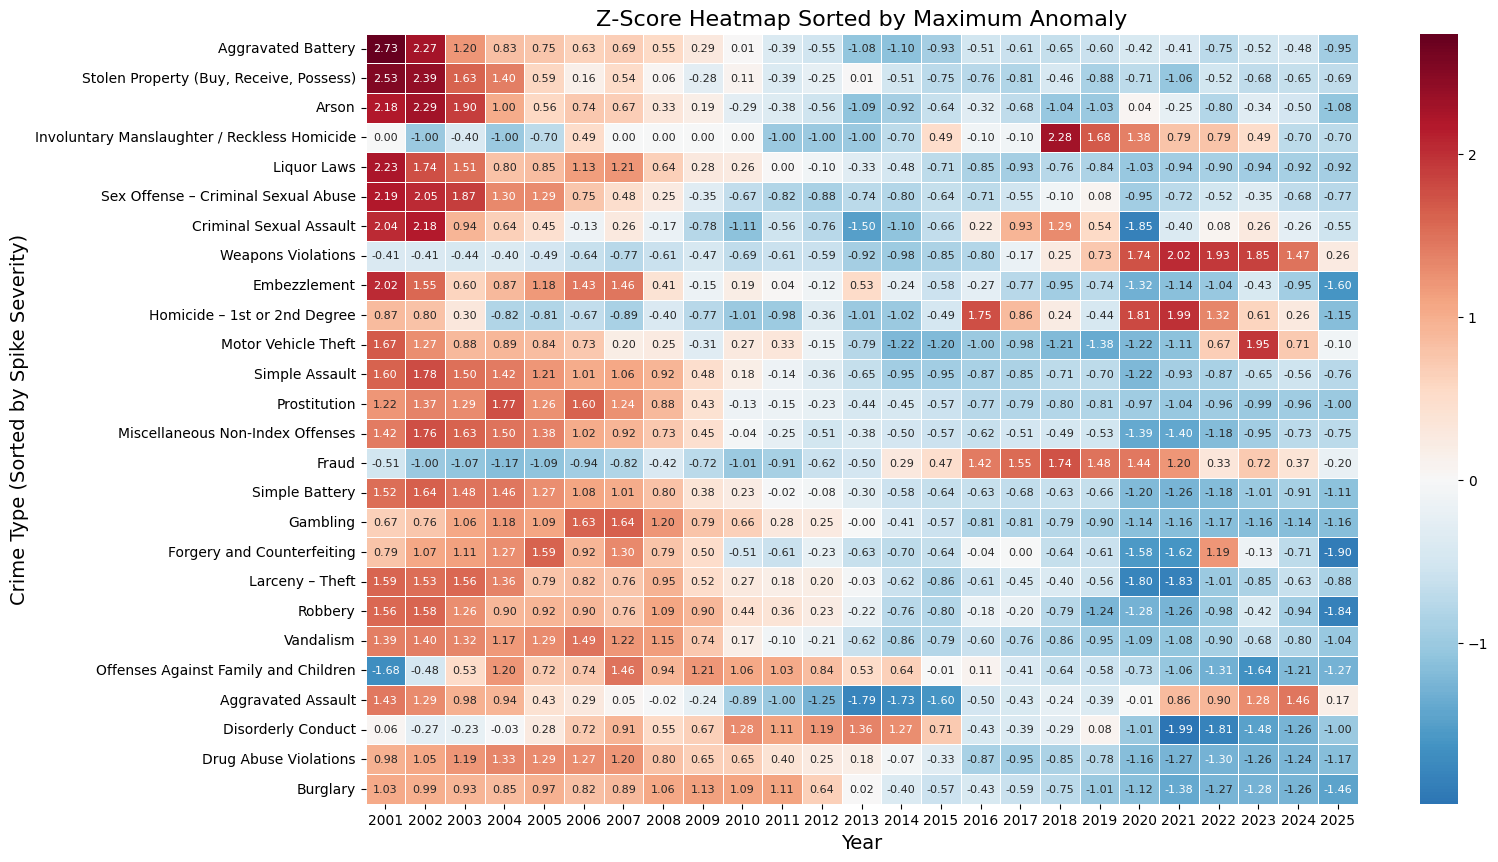

In [5]:
# Sort columns by maximum z‑score (years with biggest spikes first)
# z_sorted_cols = z_pivot[z_pivot.max().sort_values(ascending=False).index]

# Sort crime types by their highest z-score across all years 
z_sorted = z_pivot.loc[z_pivot.max(axis=1).sort_values(ascending=False).index]

# Create the Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    z_sorted,
    cmap="RdBu_r",         # Red for high Z-scores, Blue for low
    center=0,              # White represents the mean
    annot=True,            # Change to False if you don't want to see the numbers
    fmt=".2f",             # format as integers
    annot_kws={"size": 8}, # change font size here
    linewidths=.5
)
plt.title("Z‑Score Heatmap Sorted by Maximum Anomaly", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Crime Type (Sorted by Spike Severity)", fontsize=14)
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_z-score_analysis.png", dpi=600, bbox_inches='tight')
plt.show()


**Note:**
- Key Patterns:
    - Early 2000s Crime Wave (Red Peak)

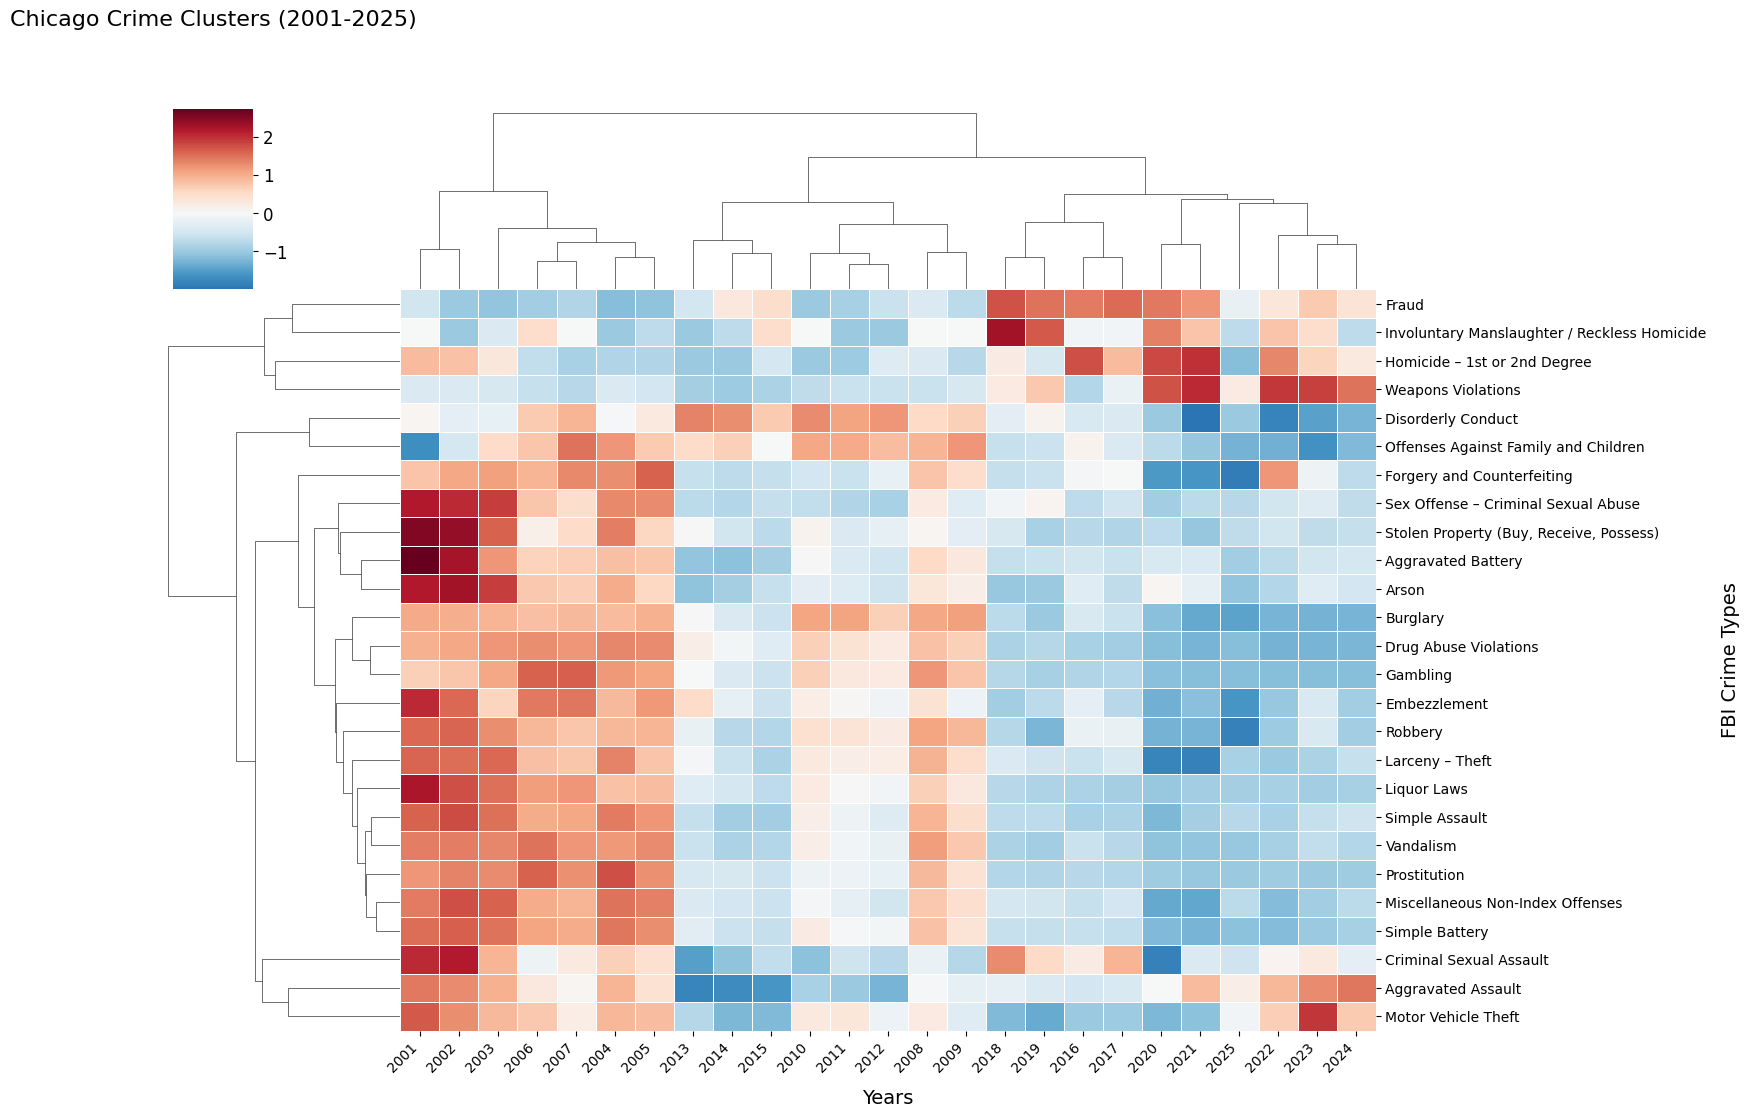

In [6]:
# Create the clustermap
g = sns.clustermap(
    z_pivot.fillna(0), 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    # col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
g.ax_heatmap.set_ylabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_xlabel('Years', fontsize=14, labelpad=10)
plt.xticks(ha='center',fontsize=8)
plt.yticks(fontsize=12)
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

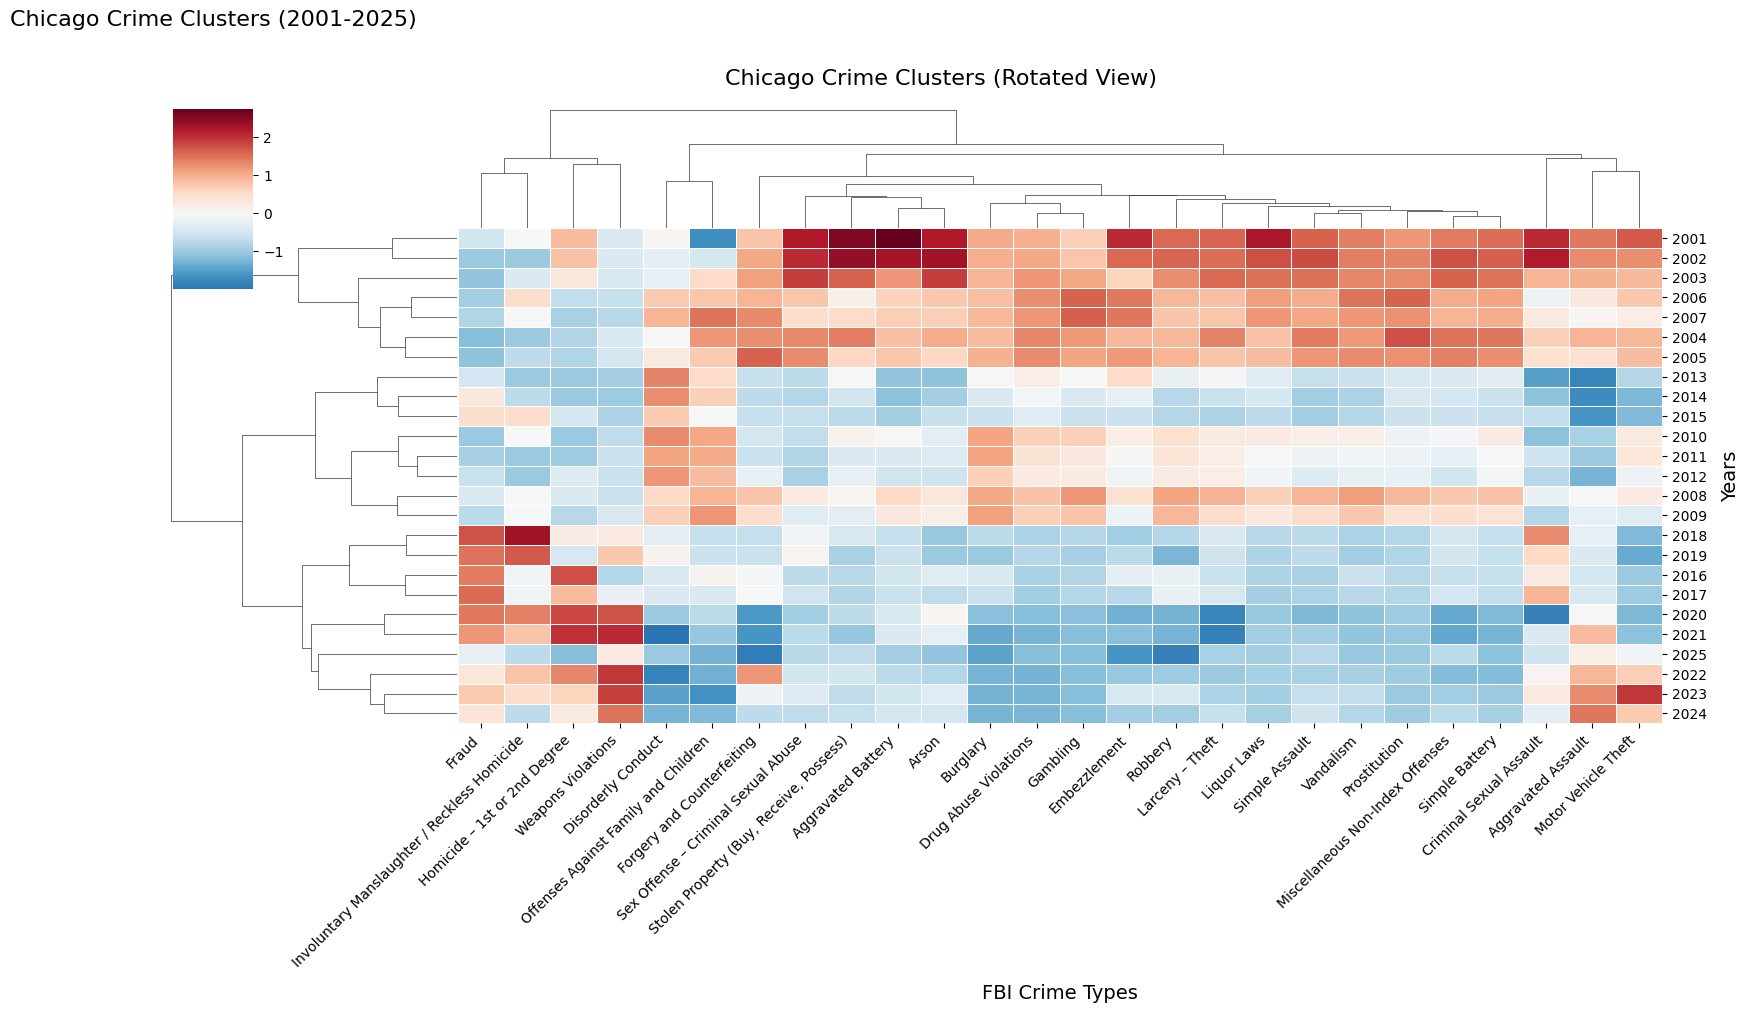

In [7]:
# .T transposes the data: Crimes become columns (X-axis), Years become index (Y-axis)
z_pivot_rotated = z_pivot.T

# Create the rotated clustermap
g = sns.clustermap(
    z_pivot_rotated.fillna(0), 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
# Labels
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters (Rotated View)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)
plt.xticks(ha='center',fontsize=8)
plt.yticks(fontsize=10)
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_rotate_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

**Note:**
1. The Color Intensity (The Values)
    - Since you are using Z-scores, look at the color first:
        - Deep Red: The crime count for that specific year was significantly above its historical average.
        - Deep Blue: The crime count for that specific year was significantly below its historical average.
        - White/Light Colors: The crime count was "normal" or very close to the 25-year mean.

2. The Dendrogram (The "Tree" Structure)
    - The branches on the top (or side) tell you how similar items are.
    - Close Neighbors: If two crime types are connected by a short "U-shaped" branch, they have very similar patterns over the 25-year period.
    - Branch Length: The longer the vertical lines of the branch before they join, the less similar those two groups are.

3. Reading the "Clusters" (The Groups)
    - The "Legacy" Cluster: Crimes that were rampant in the early 2000s but have since crashed (like Drug Abuse Violations or Prostitution). These will be Red on the top-left and deep Blue on the bottom-right.
    - The "Resilient" Cluster: Crimes that have stayed consistently high or "Red" for almost the entire 25 years. These are the persistent issues Chicago faces.
    - The "Modern Surge" Cluster: Crimes that were blue for years but have recently turned bright Red (like Motor Vehicle Theft and Weapons Violations).

4. Reading the X and Y Axis Together
    - To find a specific "Anomaly," look for a single "pop" of color that breaks a trend.
    - Vertical Red Streaks: If you see a vertical column of red across many crimes for a single year (like 2020), it suggests an External Event (like the Pandemic or civil unrest) affected almost everything at once.
    - Horizontal Red Streaks: If one crime type is red across many years, it shows a long-term sustained increase for that specific category.

5. Why the "Rotation" Helps
    - By rotating the plot, you can now scan horizontally to see which crimes behave similarly in the same year, and scan vertically to see how a single crime's "fortune" has changed from 2001 to 2025.

- Pro-Tip: The "Pivot Point"
    -Look for where the colors flip from Blue to Red. In Chicago's data, there is often a "pivot" around 2016 and 2020. These are the years where the "old" patterns of crime significantly shifted into the "modern" patterns we see today.

In [8]:
from scipy.cluster.hierarchy import fcluster

# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
z_pivot_rotated = z_pivot.T 

# Get the linkage and clusters
linkage = g.dendrogram_col.linkage 
clusters = fcluster(linkage, t=8, criterion='maxclust')

# Create the mapping using .columns instead of .index
# This matches the names on the X-axis of your rotated plot
crime_groups = pd.DataFrame({
    'fbi_code_desc': z_pivot_rotated.columns, 
    'cluster_id': clusters
}).sort_values('cluster_id')

# Display the members
for cluster_num in range(1, 9):
    members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
    print(f"--- Cluster {cluster_num} ---")
    print("\n".join([f"  • {m}" for m in members]))
    print("-" * 30)

--- Cluster 1 ---
  • Involuntary Manslaughter / Reckless Homicide
  • Fraud
------------------------------
--- Cluster 2 ---
  • Homicide – 1st or 2nd Degree
------------------------------
--- Cluster 3 ---
  • Weapons Violations
------------------------------
--- Cluster 4 ---
  • Disorderly Conduct
  • Offenses Against Family and Children
------------------------------
--- Cluster 5 ---
  • Liquor Laws
  • Sex Offense – Criminal Sexual Abuse
  • Robbery
  • Prostitution
  • Stolen Property (Buy, Receive, Possess)
  • Miscellaneous Non-Index Offenses
  • Burglary
  • Larceny – Theft
  • Vandalism
  • Aggravated Battery
  • Gambling
  • Arson
  • Forgery and Counterfeiting
  • Embezzlement
  • Drug Abuse Violations
  • Simple Assault
  • Simple Battery
------------------------------
--- Cluster 6 ---
  • Aggravated Assault
------------------------------
--- Cluster 7 ---
  • Motor Vehicle Theft
------------------------------
--- Cluster 8 ---
  • Criminal Sexual Assault
--------------

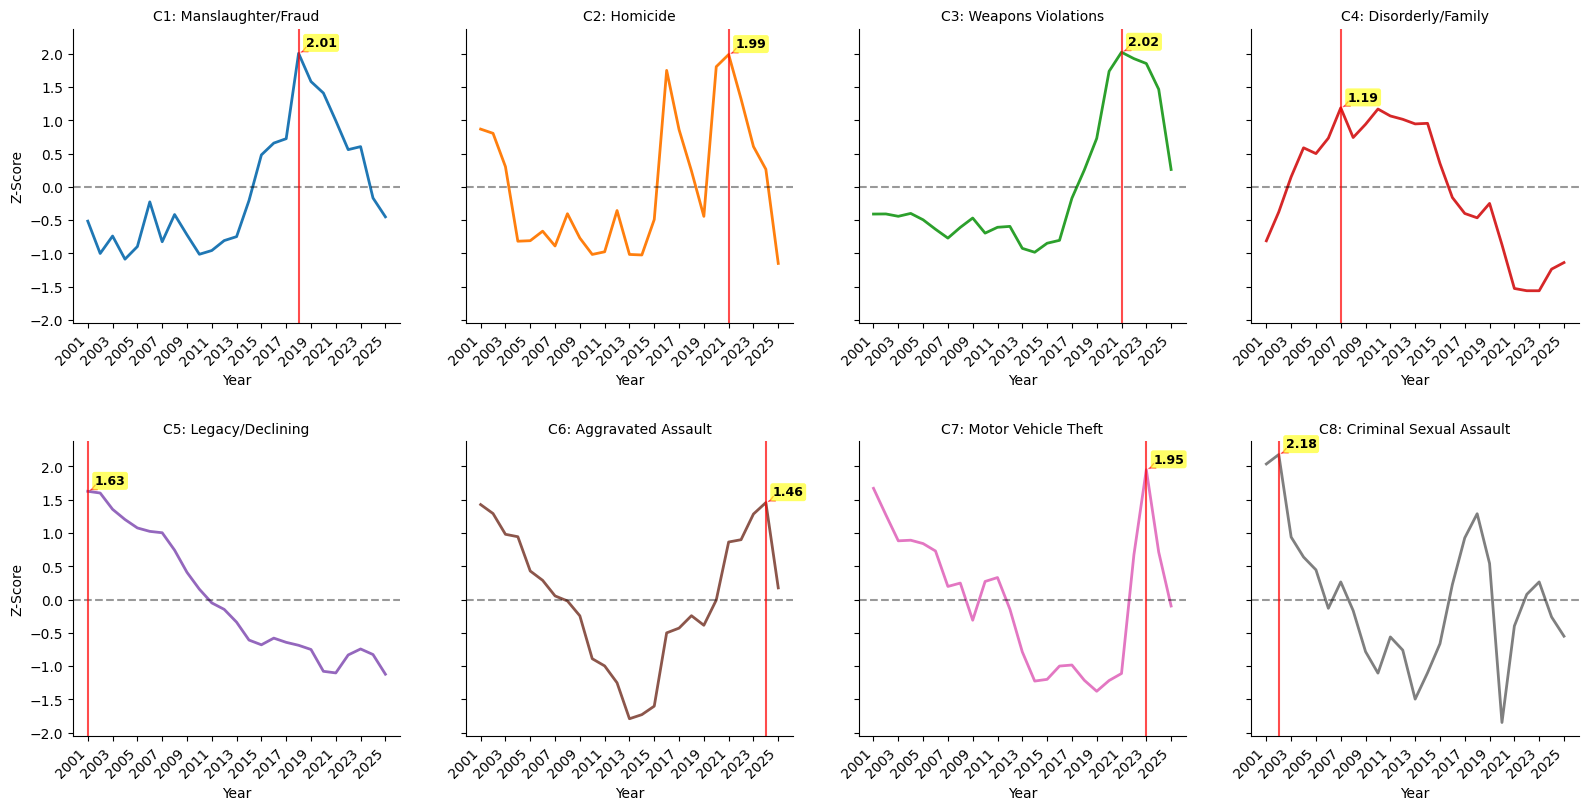

In [9]:
# Aggregate Data INTO 'cluster_trends' ---
yearly_with_clusters = yearly.merge(crime_groups, on='fbi_code_desc')
cluster_trends = (
    yearly_with_clusters.groupby(['cluster_id', 'year'])['z_score']
    .mean()
    .reset_index()
)

# Define Names Mapping
cluster_names = {
    1: "C1: Manslaughter/Fraud",
    2: "C2: Homicide",
    3: "C3: Weapons Violations",
    4: "C4: Disorderly/Family",
    5: "C5: Legacy/Declining",
    6: "C6: Aggravated Assault",
    7: "C7: Motor Vehicle Theft",
    8: "C8: Criminal Sexual Assault"
}
cluster_trends['story'] = cluster_trends['cluster_id'].map(cluster_names)

# Pre-calculate values to avoid filtering inside the loop
# This ensures we only iterate through the axes and relevant data slices
grouped = cluster_trends.groupby('story')

# Create the grid
g = sns.FacetGrid(
    cluster_trends, col="story", col_wrap=4, hue="story",
    height=4, aspect=1.0, sharex=False
)

# Map primary elements
g.map(plt.plot, "year", "z_score", linewidth=2)
g.map(plt.axhline, y=0, color='black', linestyle='--', alpha=0.4)
g.set_titles("{col_name}")

years = sorted(cluster_trends['year'].unique())

# Iterate using zip to link axes with grouped data efficiently
for (story_name, facet_data), ax in zip(grouped, g.axes.flat):
    
    if not facet_data.empty:
        # Using idxmax() on the slice is much faster than filtering the whole DF again
        max_row = facet_data.loc[facet_data['z_score'].idxmax()]
        max_year, max_z = max_row['year'], max_row['z_score']
        
        # Draw vertical line
        ax.axvline(x=max_year, color='red', linestyle='-', alpha=0.7, linewidth=1.5)
        
        # Annotate
        ax.annotate(
            f'{max_z:.2f}', 
            xy=(max_year, max_z), 
            xytext=(5, 5), 
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.6, edgecolor='none'),
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.6),
            fontsize=9, fontweight='bold'
        )
    
    # Standardize ticks and labels
    ax.set_xticks(years[::2])
    ax.set_xticklabels(years[::2], rotation=45, ha='right')
    ax.set_xlabel("Year")
    ax.set_ylabel("Z-Score")

# Final Layout
g.fig.subplots_adjust(hspace=0.4, wspace=0.2)
# Save the figure with high resolution and tight cropping
g.savefig("../Image/cluster_trends_analysis.png", dpi=600, bbox_inches='tight')
plt.show()